# Notebook 03 — Savitzky-Golay Preprocessing

This notebook applies **Savitzky-Golay (SG) smoothing** to the raw NIR spectra.

SG smoothing is a standard preprocessing step in NIR spectroscopy.  It removes
high-frequency instrumental noise while keeping the shape of absorption peaks
intact — which matters when we later train a classifier on those peak features.

**Input :** `data/processed/labeled.csv` (produced by `02_labeling.ipynb`)  
**Output :** `data/processed/X_preprocessed.npy`, `data/processed/y_labels.npy`,
`data/processed/sample_ids.npy`

## Section 1 — Imports and Setup

Here we import all the third-party libraries we need (`numpy`, `pandas`,
`matplotlib`, `seaborn`) and our own helper functions from `src/`.  We also
set a consistent visual style for all plots and fix `random_state = 42` so
that any step involving randomness is reproducible.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Allow notebooks to import from the project src/ directory
sys.path.append('..')
from src.data_loader import load_labeled_data
from src.preprocessor import (
    apply_savitzky_golay,
    plot_preprocessing_comparison,
    plot_all_preprocessed_spectra,
)

# Set a clean, publication-ready visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Fix random seed for reproducibility
random_state = 42
np.random.seed(random_state)

print('All imports successful.')
print(f'NumPy version  : {np.__version__}')
print(f'Pandas version : {pd.__version__}')

All imports successful.
NumPy version  : 2.4.4
Pandas version : 3.0.2


## Section 2 — Load the Labeled Dataset

We load the processed CSV that was created in `02_labeling.ipynb`.  The
`load_labeled_data()` function returns three objects:

| Variable | Description |
|----------|-------------|
| `X` | Raw NIR absorbance matrix — shape `(n_samples, 700)` |
| `y` | Binary protein labels — `1` = High Protein, `0` = Low Protein |
| `sample_ids` | List of sample identifier strings |

> **Note:** At this point `X` still contains the **raw, unpreprocessed** spectra.
> Smoothing is applied in Section 3.

In [2]:
X, y, sample_ids = load_labeled_data('../data/processed/labeled.csv')

print()
print(f'Shape of X (raw spectra)      : {X.shape}  — {X.shape[0]} samples, {X.shape[1]} wavelength channels')
print(f'Shape of y (protein labels)   : {y.shape}  — {int((y == 1).sum())} High Protein, {int((y == 0).sum())} Low Protein')
print(f'Number of sample IDs          : {len(sample_ids)}')

Labeled data loaded: 539 samples
X shape  : (539, 700)
y shape  : (539,)  —  classes: [0, 1]

Shape of X (raw spectra)      : (539, 700)  — 539 samples, 700 wavelength channels
Shape of y (protein labels)   : (539,)  — 289 High Protein, 250 Low Protein
Number of sample IDs          : 539


## Section 3 — Apply Savitzky-Golay Smoothing

We now pass the raw spectra through the `apply_savitzky_golay()` function.
The three parameters below were chosen carefully:

| Parameter | Value | Reason |
|-----------|-------|--------|
| `window_length` | 11 | Based on prior literature that uses this exact Eigenvector corn dataset; an 11-point window smooths well without broadening peaks |
| `polyorder` | 2 | A second-degree polynomial preserves peak shapes (curvature) better than a linear (`polyorder=1`) fit |
| `deriv` | 0 | Pure smoothing only — no differentiation.  This is the simplest and most common first step, and is easier to justify to a thesis panel than computing derivatives |

The output `X_smoothed` has exactly the same shape as `X`; only the values
change (noise is reduced).

In [3]:
X_smoothed = apply_savitzky_golay(X, window_length=11, polyorder=2, deriv=0)

print()
print(f'Shape of X         (raw)     : {X.shape}')
print(f'Shape of X_smoothed (smooth) : {X_smoothed.shape}')
print('Shapes match:', X.shape == X_smoothed.shape)

Applying Savitzky-Golay smoothing with the following parameters:
  window_length : 11
  polyorder     : 2
  deriv         : 0
Smoothing complete. Output shape: (539, 700)

Shape of X         (raw)     : (539, 700)
Shape of X_smoothed (smooth) : (539, 700)
Shapes match: True


## Section 4 — Compare Raw vs. Smoothed Spectra

To verify that the filter is working correctly, we plot the raw and smoothed
versions of **Sample 0** on the same axes.  The light-gray curve is the raw
spectrum (with visible high-frequency fluctuations) and the steelblue curve
is the SG-smoothed version.

Smoothing is necessary before model training because high-frequency noise
does not carry useful chemical information — it only adds variance that can
mislead the classifier.  By removing it first, we help the model focus on
the true absorption peaks that are linked to protein content.

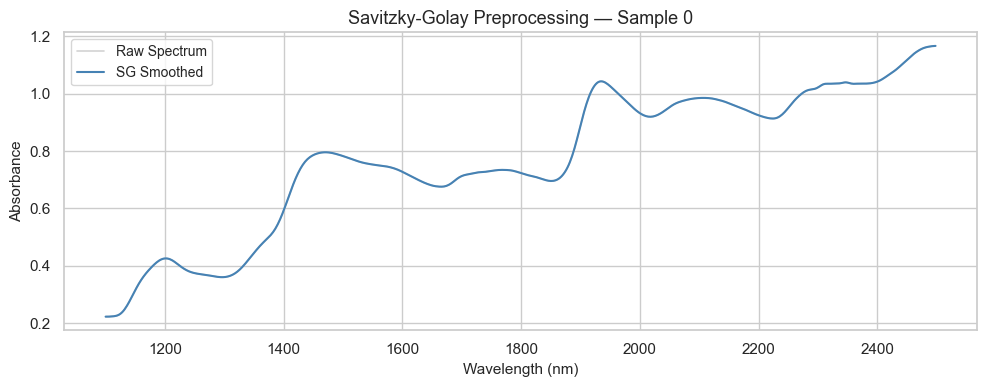

In [4]:
plot_preprocessing_comparison(X, X_smoothed, sample_idx=0)

## Section 5 — Plot All Preprocessed Spectra by Label

This plot overlays all 80 smoothed spectra at once, coloured by protein
label (red = High Protein, blue = Low Protein).  Looking at this plot
helps us check whether there are any visible spectral differences between
the two groups that a machine learning model might be able to exploit.

Even subtle shifts in peak height or position between the red and blue
groups support the hypothesis that NIR data can separate High- from
Low-Protein corn samples.

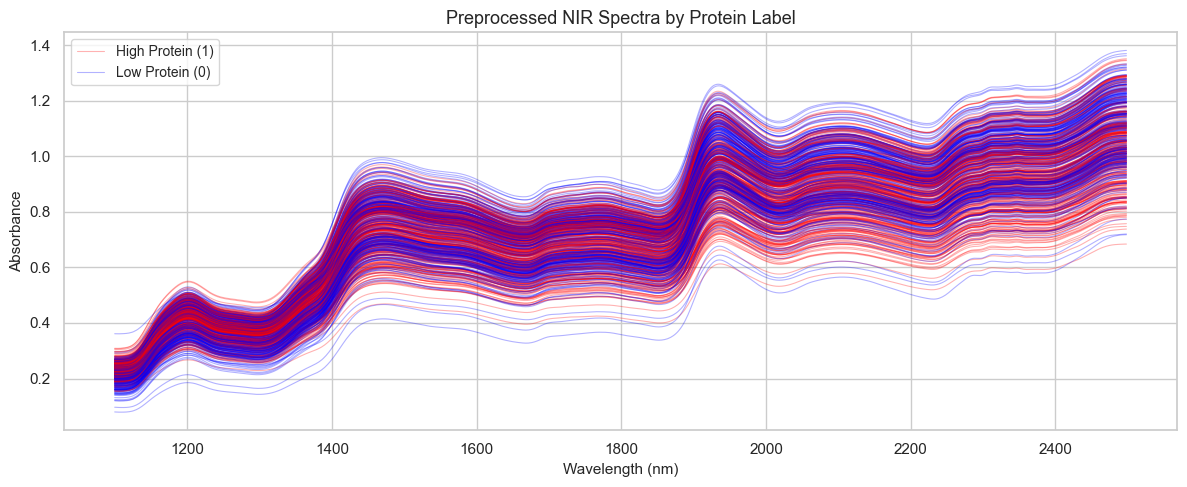

In [5]:
plot_all_preprocessed_spectra(X_smoothed, y)

## Section 6 — Save Preprocessed Spectra

We save all three arrays (`X_smoothed`, `y`, `sample_ids`) as separate
`.npy` files in `data/processed/`.  Saving them separately — rather than
as a single file — makes it easy for the next notebook to load only what
it needs.  It also keeps the arrays in their native NumPy format, which
is faster to load than CSV and preserves exact floating-point values.

All three files will be loaded together at the start of
`04_augmentation.ipynb`.

In [6]:
import os

output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

np.save(os.path.join(output_dir, 'X_preprocessed.npy'), X_smoothed)
print(f'Saved X_preprocessed.npy  — shape: {X_smoothed.shape}')

np.save(os.path.join(output_dir, 'y_labels.npy'), y)
print(f'Saved y_labels.npy        — shape: {y.shape}')

np.save(os.path.join(output_dir, 'sample_ids.npy'), np.array(sample_ids))
print(f'Saved sample_ids.npy      — {len(sample_ids)} entries')

print()
print('All files saved successfully to:', os.path.abspath(output_dir))

Saved X_preprocessed.npy  — shape: (539, 700)
Saved y_labels.npy        — shape: (539,)
Saved sample_ids.npy      — 539 entries

All files saved successfully to: c:\Users\kervi\Documents\nir-maize-classifier\data\processed


## Section 7 — Summary

This notebook completed the **Savitzky-Golay preprocessing** step for the
NIR corn dataset.  Here is a quick recap:

| Item | Detail |
|------|---------|
| **Preprocessing method** | Savitzky-Golay smoothing (`scipy.signal.savgol_filter`) |
| **Parameters** | `window_length=11`, `polyorder=2`, `deriv=0` |
| **Input** | Raw spectra from `data/processed/labeled.csv` |
| **Output — spectra** | `data/processed/X_preprocessed.npy` |
| **Output — labels** | `data/processed/y_labels.npy` |
| **Output — sample IDs** | `data/processed/sample_ids.npy` |

**Next step:** `04_augmentation.ipynb` will load these three `.npy` files
and expand the training set using **linear interpolation augmentation** to
generate additional synthetic samples between existing spectra.  This helps
improve model robustness when the original dataset is small (80 samples).